# Classification Track — Part A — Loan Status Prediction
**23CSE301 Machine Learning Capstone — Review 1**

Pipeline: data loading → EDA → cleaning & feature engineering → 5 Part-A classification
algorithms (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM) → evaluation
(Accuracy, Precision, Recall, F1-weighted, Confusion Matrix) → preliminary comparison table.

Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) plus the full 10-model
comparison and ROC-AUC are completed in Review 2, on this same dataset and split.


In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (8, 5)

## Section A — Dataset Loading & EDA

### A1. Dataset loading & audit

In [12]:
DATA_PATH = "../data/Loan_approval_data_2025.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (50000, 20)


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None found.")


Columns with missing values:
None found.


In [15]:
target = 'loan_status'
print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True).round(3))


loan_status
1    27523
0    22477
Name: count, dtype: int64

loan_status
1    0.55
0    0.45
Name: proportion, dtype: float64


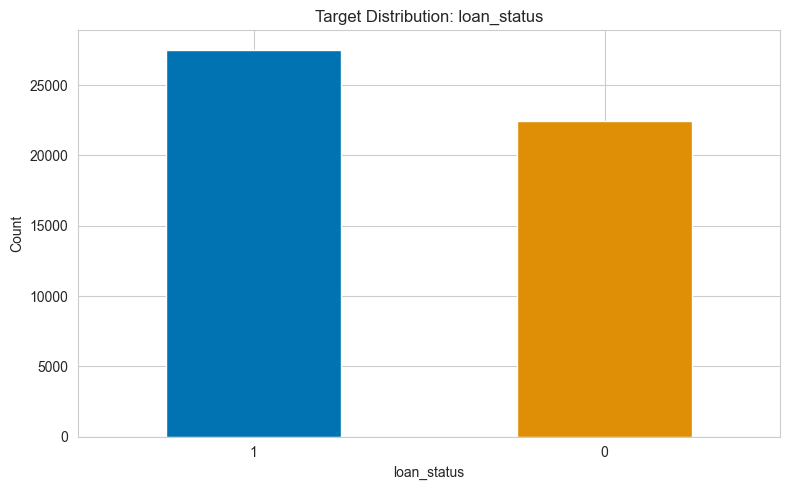

In [16]:
ax = df[target].value_counts().plot(kind='bar', color=sns.color_palette('colorblind'))
plt.title('Target Distribution: loan_status')
plt.xlabel('loan_status'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** *(fill in after running — note whether classes are imbalanced; if so, mention that this motivates using weighted F1 / stratified split rather than raw accuracy.)*

### A2. EDA Visualisations

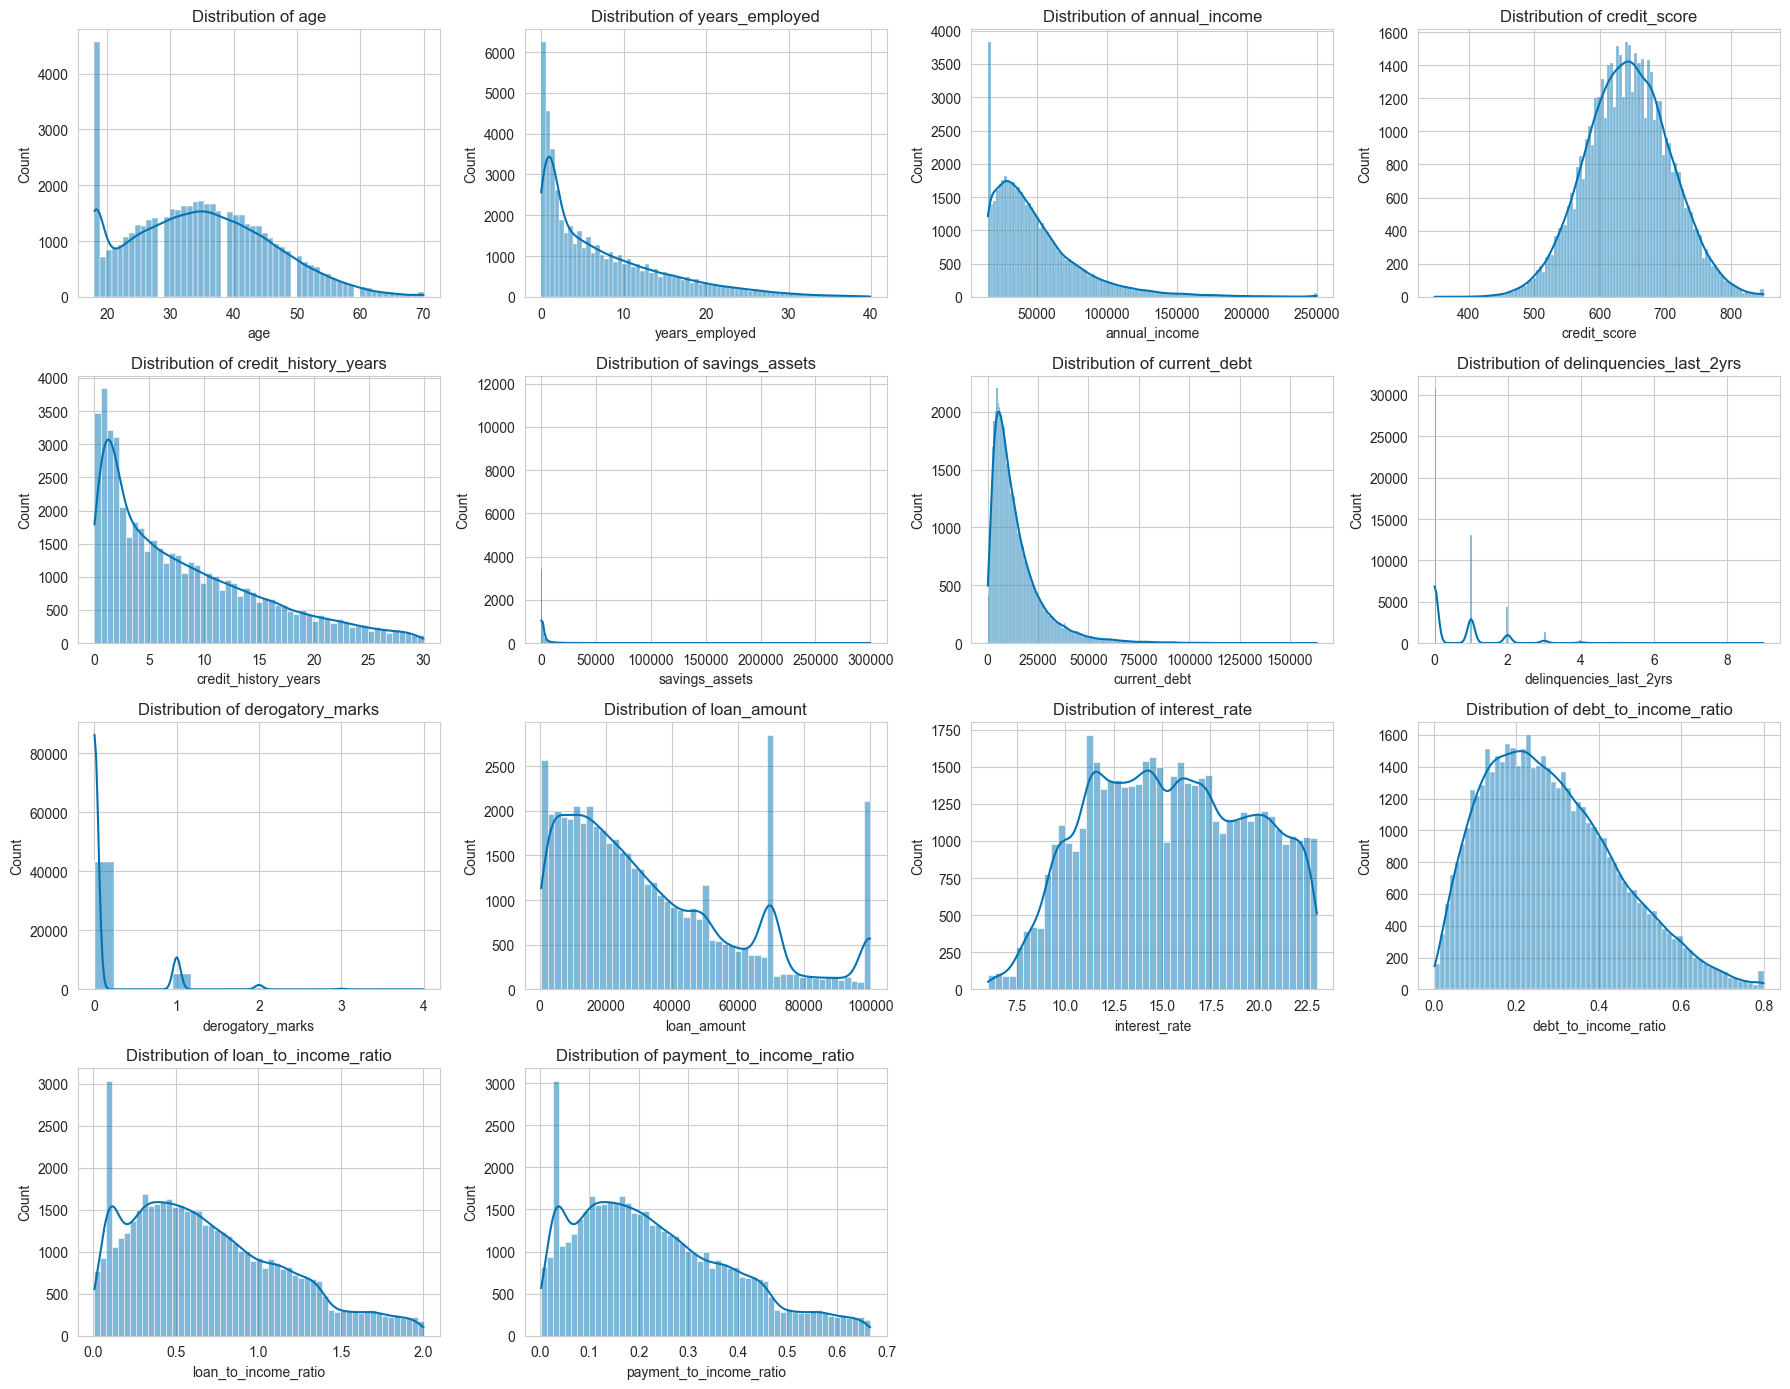

In [17]:
num_cols = ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years',
            'savings_assets', 'current_debt', 'delinquencies_last_2yrs', 'derogatory_marks',
            'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio',
            'payment_to_income_ratio']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {c}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


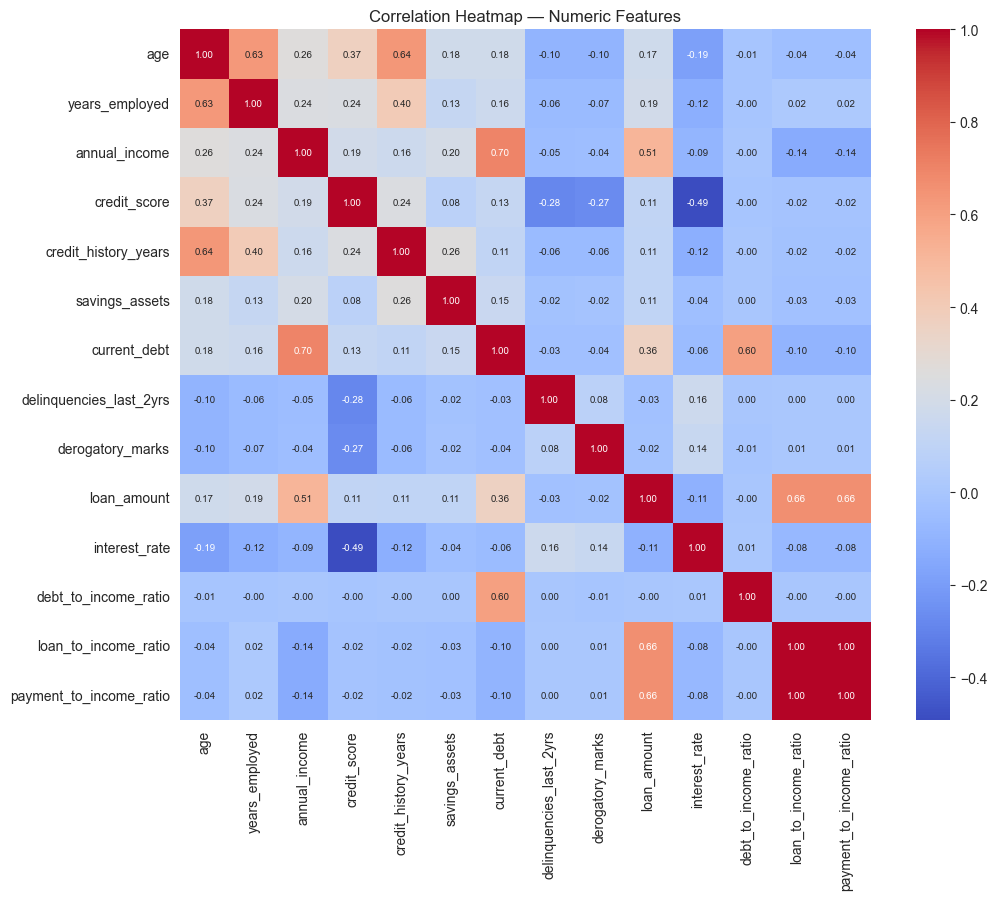

In [18]:
plt.figure(figsize=(11,9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True,
            annot_kws={'size': 7})
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()


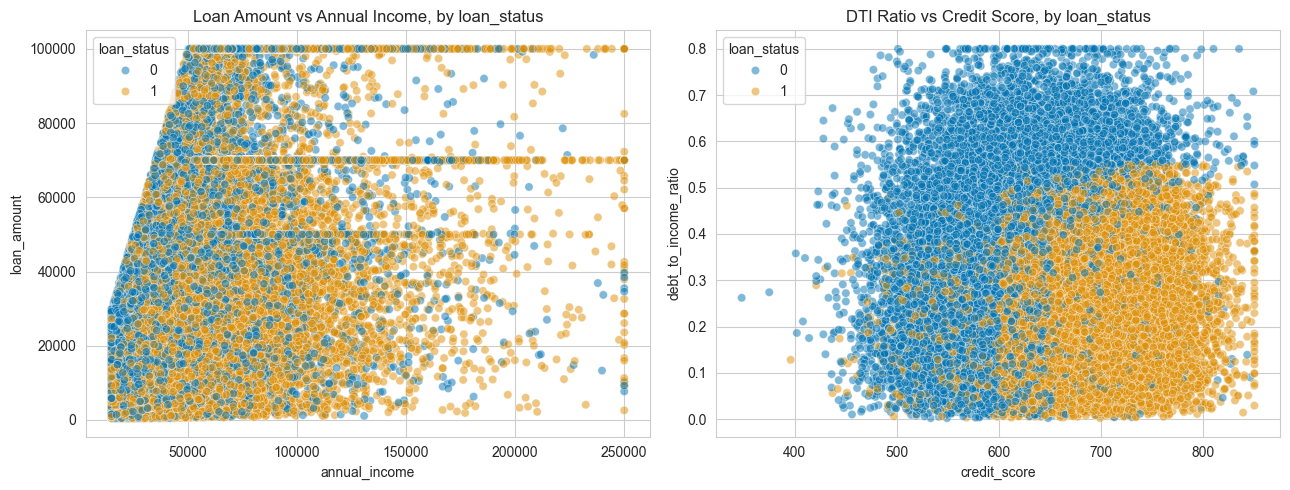

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=df, x='annual_income', y='loan_amount', hue=target, alpha=0.5, ax=axes[0])
axes[0].set_title('Loan Amount vs Annual Income, by loan_status')

sns.scatterplot(data=df, x='credit_score', y='debt_to_income_ratio', hue=target, alpha=0.5, ax=axes[1])
axes[1].set_title('DTI Ratio vs Credit Score, by loan_status')
plt.tight_layout()
plt.show()


**Observation:** *(fill in — e.g. note whether declined/defaulted loans cluster at high DTI and low credit_score, and whether income vs loan_amount separates the classes visually.)*

## Section B — Preprocessing & Feature Engineering

### B1. Data cleaning

In [20]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df = df.drop_duplicates()

# Outlier check via IQR on key skewed numeric columns
for col in ['annual_income', 'loan_amount', 'current_debt']:
    if col in df.columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"{col}: {n_out} potential outliers outside [{lower:.0f}, {upper:.0f}]")

# Strategy: cap at 1st/99th percentile instead of dropping rows (avoid losing genuine
# high-income / high-loan-amount applicants, which are meaningful, not noise).
for col in ['annual_income', 'loan_amount', 'current_debt']:
    if col in df.columns:
        low, high = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(low, high)


Duplicate rows: 0
annual_income: 2355 potential outliers outside [-25884, 115887]
loan_amount: 0 potential outliers outside [-42000, 102800]
current_debt: 2932 potential outliers outside [-13721, 37752]


In [21]:
drop_cols = [c for c in ['customer_id'] if c in df.columns]
df = df.drop(columns=drop_cols)
print("Dropped identifier columns:", drop_cols)


Dropped identifier columns: ['customer_id']


### B2. Encoding, scaling & splitting

In [22]:
y_raw = df[target]
X = df.drop(columns=[target])

categorical_cols = [c for c in ['occupation_status', 'product_type', 'loan_intent',
                                 'defaults_on_file'] if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

# Encode target if it's text (e.g. 'Approved'/'Denied' or 'Default'/'Fully Paid')
if y_raw.dtype == object:
    classes = sorted(y_raw.unique())
    class_map = {c: i for i, c in enumerate(classes)}
    y = y_raw.map(class_map)
    print("Target classes:", class_map)
else:
    y = y_raw

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)


Numeric: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio']
Categorical: ['occupation_status', 'product_type', 'loan_intent', 'defaults_on_file']
(40000, 18) (10000, 18)


In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


### B3. Feature engineering

In [24]:
# Engineered feature: disposable_income_ratio — how much income remains after
# covering current debt, as a fraction of annual income. This can capture repayment
# capacity in a way no single existing ratio column does directly.
for split_df in (X_train, X_test):
    split_df['disposable_income_ratio'] = (
        (split_df['annual_income'] - split_df['current_debt']) / split_df['annual_income']
    )
numeric_cols = numeric_cols + ['disposable_income_ratio']

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


**Justification:** two applicants with identical `debt_to_income_ratio` can differ in how much *absolute* buffer income they retain after debt obligations — `disposable_income_ratio` captures this repayment-capacity signal.

## Section D — Classification Track, Part A: 5 Algorithms

In [25]:
results = {}

def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec = recall_score(y_te, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_te, preds, average='weighted', zero_division=0)
    results[name] = {'model': pipeline, 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1_weighted': f1, 'preds': preds}
    print(f"{name:28s} Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return pipeline


In [26]:
# 1. Logistic Regression (baseline)
log_pipe = Pipeline([('prep', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
evaluate('Logistic Regression', log_pipe, X_train, y_train, X_test, y_test)

# Interpret coefficients / odds ratios
log_model = results['Logistic Regression']['model'].named_steps['model']
feature_names = results['Logistic Regression']['model'].named_steps['prep'].get_feature_names_out()
if log_model.coef_.shape[0] == 1:
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': log_model.coef_[0]})
    coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
    print(coef_df.sort_values('coefficient', key=abs, ascending=False).head(10))


Logistic Regression          Acc=0.8654  Prec=0.8653  Rec=0.8654  F1=0.8653
                                feature  coefficient  odds_ratio
28              cat__defaults_on_file_1    -5.730899    0.003244
27              cat__defaults_on_file_0     3.830022   46.063567
11            num__debt_to_income_ratio    -3.796493    0.022449
19     cat__product_type_Line of Credit    -2.735698    0.064849
14         num__disposable_income_ratio    -2.335023    0.096808
18        cat__product_type_Credit Card     2.316035   10.135406
22  cat__loan_intent_Debt Consolidation    -2.005320    0.134617
10                   num__interest_rate    -1.999623    0.135386
20      cat__product_type_Personal Loan    -1.481213    0.227362
23           cat__loan_intent_Education     1.331445    3.786511


In [32]:
# 2. K-Nearest Neighbors (tune k, note: distance metrics matter more with mixed
# numeric/one-hot data; default Minkowski/Euclidean used here)
best_knn, best_k, best_f1 = None, None, -1
for k in [3, 5, 7, 9, 11, 15]:
    pipe = Pipeline([('prep', preprocessor), ('model', KNeighborsClassifier(n_neighbors=k,n_jobs=1))])
    pipe.fit(X_train, y_train)
    f1 = f1_score(y_test, pipe.predict(X_test), average='weighted')
    if f1 > best_f1:
        best_f1, best_k, best_knn = f1, k, pipe
print(f"Best k = {best_k} (weighted F1 = {best_f1:.4f})")
evaluate('K-Nearest Neighbors', best_knn, X_train, y_train, X_test, y_test)


Best k = 15 (weighted F1 = 0.8738)
K-Nearest Neighbors          Acc=0.8748  Prec=0.8774  Rec=0.8748  F1=0.8738


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio',
                                                   'disposable_income_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent',
                                                   'defaults_on_file'])])),
                ('model', KNeighborsClassifier(n_jobs=1, n_neighbors=15))])

In [28]:
# 3. Naive Bayes (Gaussian) — assumes conditional independence of features given the class;
# a strong assumption here since e.g. loan_amount and loan_to_income_ratio are correlated.
nb_pipe = Pipeline([('prep', preprocessor), ('model', GaussianNB())])
evaluate('Naive Bayes (Gaussian)', nb_pipe, X_train, y_train, X_test, y_test)


Naive Bayes (Gaussian)       Acc=0.6195  Prec=0.7706  Rec=0.6195  F1=0.5295


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio',
                                                   'disposable_income_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent',
                                                   'defaults_on_file'])])),
                ('model', GaussianNB())])

In [29]:
# 4. Decision Tree Classifier (tune max_depth, visualise tree)
best_dt, best_depth, best_f1 = None, None, -1
for depth in [3, 5, 7, 10, None]:
    pipe = Pipeline([('prep', preprocessor), ('model', DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train)
    f1 = f1_score(y_test, pipe.predict(X_test), average='weighted')
    if f1 > best_f1:
        best_f1, best_depth, best_dt = f1, depth, pipe
print(f"Best max_depth = {best_depth} (weighted F1 = {best_f1:.4f})")
evaluate('Decision Tree Classifier', best_dt, X_train, y_train, X_test, y_test)


Best max_depth = 10 (weighted F1 = 0.8882)
Decision Tree Classifier     Acc=0.8884  Prec=0.8884  Rec=0.8884  F1=0.8882


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_in..._ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio',
                                                   'disposable_income_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent',
                                                   'defaults_on_file'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=10, random_state=42))])

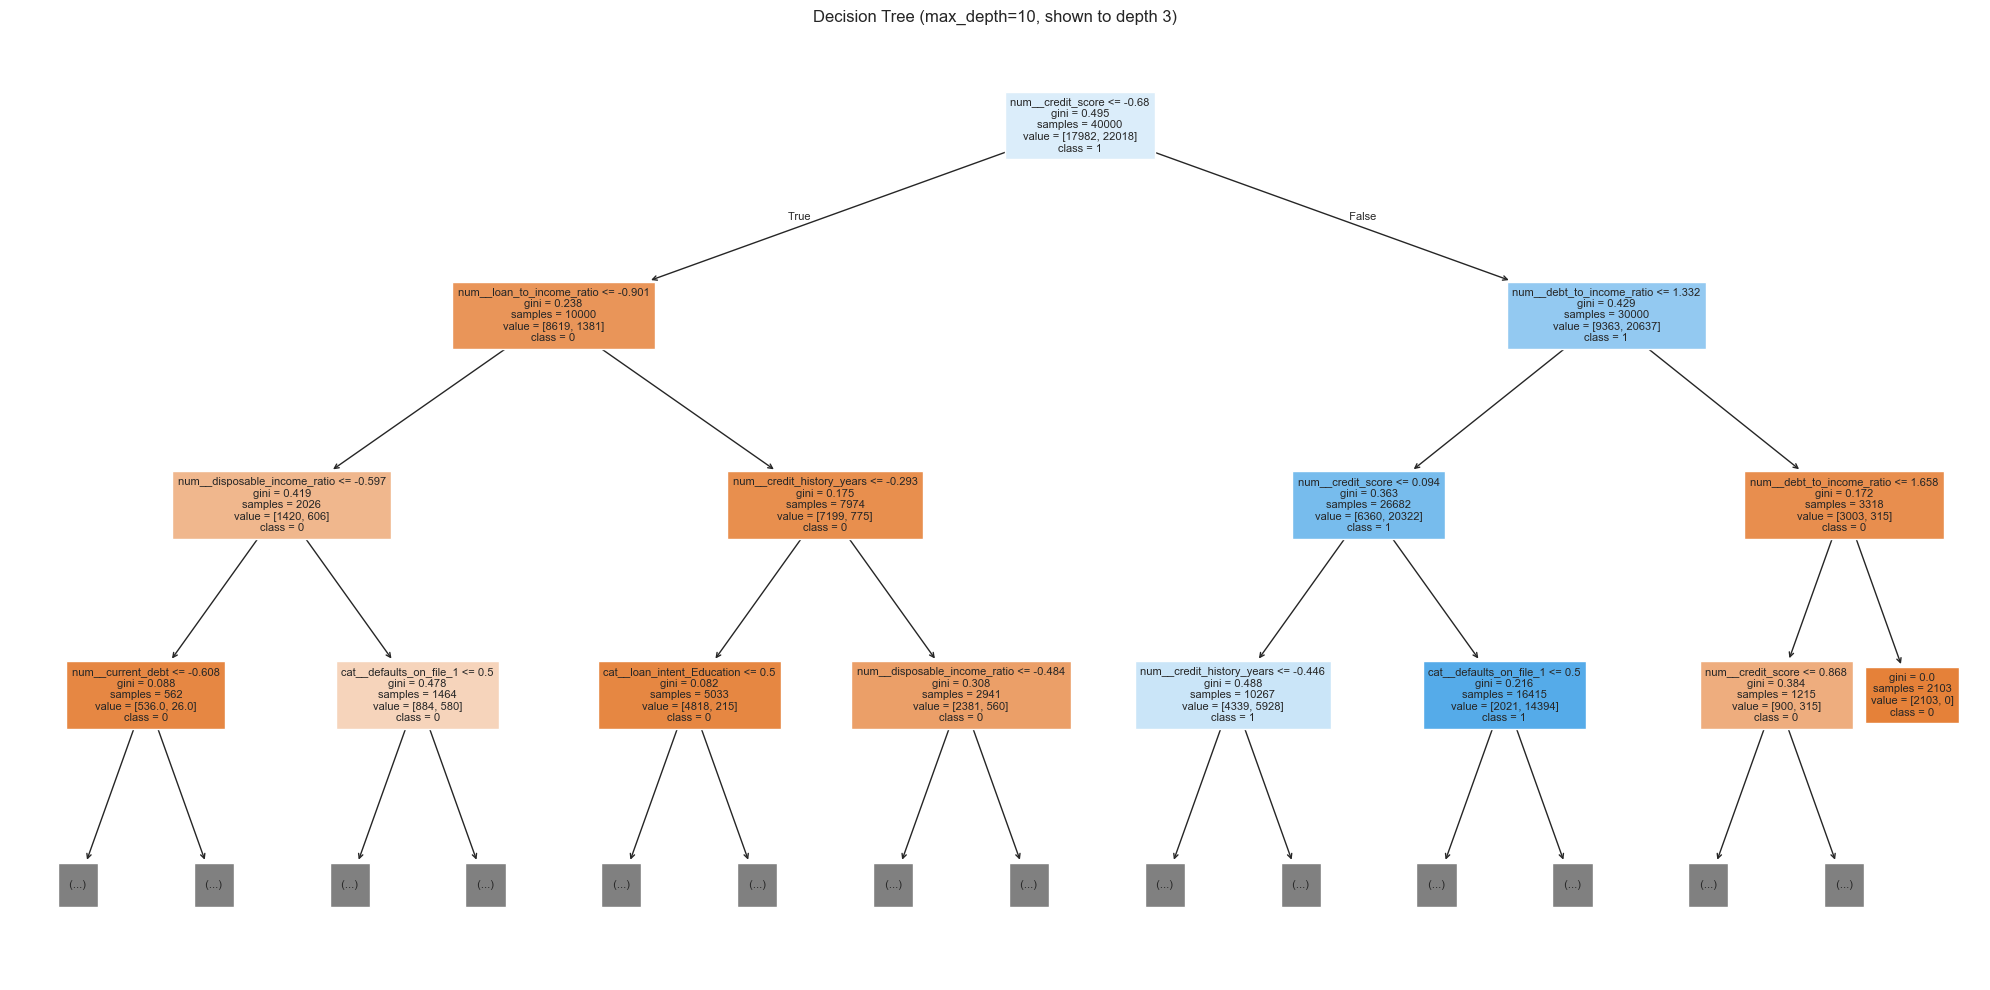

In [30]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt.named_steps['model'], max_depth=3, feature_names=feature_names,
          class_names=[str(c) for c in sorted(y.unique())], filled=True, fontsize=8)
plt.title(f'Decision Tree (max_depth={best_depth}, shown to depth 3)')
plt.tight_layout()
plt.show()


In [33]:
# 5. Support Vector Machine (SVC) — tune C and kernel; features already scaled in preprocessor
X_s, y_s = X_train.iloc[:2500], y_train.iloc[:2500]
best_svc, best_params, best_f1 = None, None, -1.0

for C in [0.5, 1.0, 5.0]:
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', SVC(C=C, kernel='rbf', max_iter=1000, random_state=RANDOM_STATE))
    ]).fit(X_s, y_s)
    f1 = f1_score(y_test, pipe.predict(X_test), average='weighted')
    if f1 > best_f1:
        best_f1, best_params, best_svc = f1, {'C': C, 'kernel': 'rbf'}, pipe

print(f"Best params (SVC) = {best_params} (weighted F1 = {best_f1:.4f})")
evaluate('Support Vector Machine', best_svc, X_s, y_s, X_test, y_test)

Best params (SVC) = {'C': 5.0, 'kernel': 'rbf'} (weighted F1 = 0.8936)
Support Vector Machine       Acc=0.8936  Prec=0.8935  Rec=0.8936  F1=0.8936


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio',
                                                   'disposable_income_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent',
                                                   'defaults_on_file'])])),
                ('model', SVC(C=5.0, max_iter=1000, random_state=42))])

### D2. Evaluation — Confusion Matrices & Preliminary Comparison Table

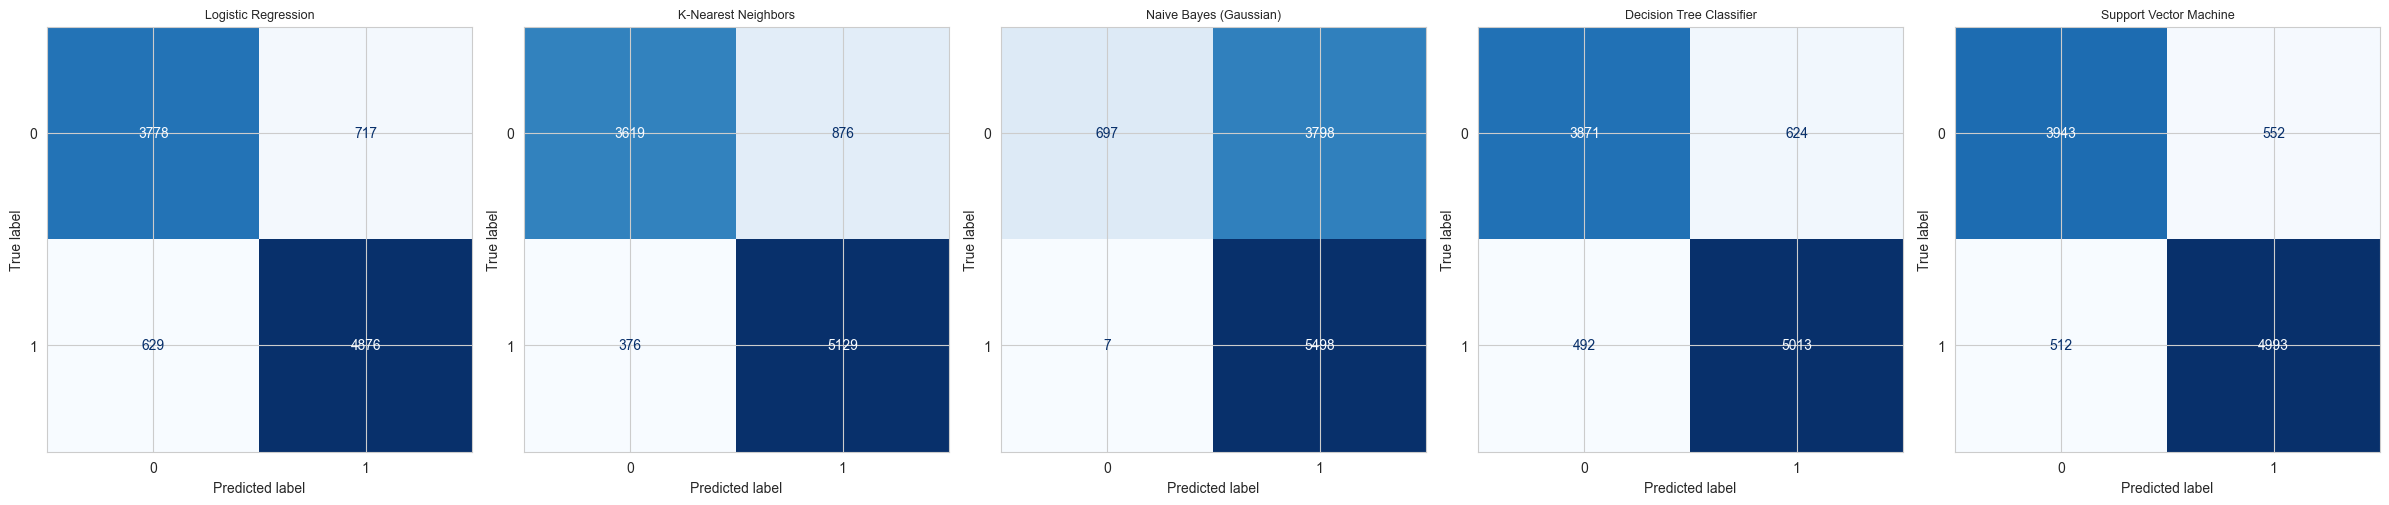

In [34]:
class_labels = sorted(y.unique())
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'], labels=class_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()


In [35]:
summary = pd.DataFrame({
    name: {'Accuracy': r['Accuracy'], 'Precision': r['Precision'],
           'Recall': r['Recall'], 'F1_weighted': r['F1_weighted']}
    for name, r in results.items()
}).T.sort_values('F1_weighted', ascending=False)

summary.style.background_gradient(cmap='Greens')


,Accuracy,Precision,Recall,F1_weighted
Support Vector Machine,0.893600,0.893538,0.893600,0.893555
Decision Tree Classifier,0.888400,0.888373,0.888400,0.888230
K-Nearest Neighbors,0.874800,0.877388,0.874800,0.873833
Logistic Regression,0.865400,0.865272,0.865400,0.865268
Naive Bayes (Gaussian),0.619500,0.770617,0.619500,0.529503


## Summary — Part A

- Report which of the 5 algorithms performed best on weighted F1 once run on real data.
- Note class balance and whether it affected which metric (accuracy vs F1) is more trustworthy here.
- Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP), the full 10-model
  comparison table, and ROC-AUC (OvR if multi-class) are completed in Review 2 on this
  same `X_train`/`X_test` split.
